# Equilibrium disorder: size dependence of entropy fits
Compare $N_x=20$ and $N_y=32,36,40,44,48,80,100,120,160$ with the same hard-wall OW parent, $\alpha_1=1,\alpha_2=30,n_{\rm shell}=1$:
$$h_{\rm dis}=h_{\rm flat}-\operatorname{diag}(m_{x_i}v_i),\qquad
v_i\overset{\rm iid}{\sim}\mathcal N(0,W^2),\quad m_x=1\text{ only at }x=5,6,14,15.$$
Potentials are independent across $y$ and both orbitals; no sample demeaning and no reflattening. Occupy the globally lowest $20N_y$ energies.
Use 100 independent realizations for each nonzero $W^2=1,2,3,4,6,9,12,16,25$, plus one clean reference per size. Reuse the verified $N_y=32,36,40,44,48$ data and acquire 3600 new realizations with independent size-indexed seeds.

For every width $A_y=1,\ldots,N_y/2$, include all $x$ and both orbitals, and average **full von Neumann entropy** over all $N_y$ periodic origins within each state, then average states:
$$\bar S(A_y)=\frac1{100}\sum_s\frac1{N_y}\sum_{y_0}[-\operatorname{tr}(C_A\log C_A+(\mathbf1-C_A)\log(\mathbf1-C_A))].$$
No entanglement-energy window is used. Fit unweighted, free-intercept OLS:
$$\bar S(A_y)=s_0+\frac{c_{\rm fit}}3\log\left[\frac{N_y}{\pi}\sin\frac{\pi A_y}{N_y}\right].$$
The primary fit extends the previous range to $5\le A_y\le N_y/2$. Also retain fixed starts 2 and 8, and fixed relative starts $\lceil5N_y/32\rceil$ and $\lceil N_y/4\rceil$. This distinguishes changes in the accessible fitting interval from size dependence.

$c_{\rm fit}$ is the finite-size total-strip coefficient, not per wall. Sampling errors are one SEM of independent realization profiles; bootstrap whole realizations to retain origin and width correlations. Clean states have no disorder sampling uncertainty. We do not infer an asymptotic central charge or impose an extrapolation law from this short size range.

In [1]:
import os
CPU_RANGE=(8,39)
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for k in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[k]='1'
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


## Configuration and verified caches
Changing fit windows or figures below does not repeat ground-state calculations. run_analysis.py creates resumable per-realization NPZ files with completion receipts.

In [2]:
from pathlib import Path
import json,hashlib,subprocess
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display,Image
OUT=Path.cwd()
SIZES=[32,36,40,44,48,80,100,120,160]
VARIANCES=[1,2,3,4,6,9,12,16,25]
BOOTSTRAPS=2000
BOOTSTRAP_SEED=2026092706
def sha(p):return hashlib.sha256(p.read_bytes()).hexdigest()
profiles={};cleans={};inputs=[];acquisition={}
for ny in SIZES:
    folder=(OUT.parent/'disordered_inner_wall_depth1_central_charge_n20x32_v1' if ny==32 else
            OUT.parent/'disordered_inner_wall_depth1_central_charge_size_scan_v1'/f'Ny{ny:03d}' if ny<=48 else
            OUT/f'Ny{ny:03d}')
    receipt=json.loads((folder/'acquisition_complete.json').read_text())
    f=folder/'entropy_profiles.npz'
    assert receipt['status']=='complete' and receipt['realizations']==900 and receipt['cache_sha256']==sha(f)
    with np.load(f) as z:
        a=z['entropy_by_origin'];clean=z['clean_entropy_by_origin']
        assert a.shape==(9,100,ny//2,ny) and clean.shape==(ny//2,ny)
        assert np.array_equal(z['origins'],np.arange(ny)) and np.array_equal(z['sample_ids'],np.arange(100))
        assert np.array_equal(z['variances'],VARIANCES)
        assert np.isfinite(a).all() and np.isfinite(clean).all()
        profiles[ny]=a.mean(-1);cleans[ny]=clean.mean(-1)
    inputs.append(dict(Ny=ny,path=str(f),bytes=f.stat().st_size,sha256=sha(f)))
    acquisition[ny]=receipt
(OUT/'analysis_inputs.json').write_text(json.dumps(inputs,indent=2)+'\n')
display(pd.Series(json.loads((OUT/'input_provenance.json').read_text())['configuration']))
print('Verified 8100 disordered state profiles across nine sizes; 3600 newly acquired.')


Nx                                                                   20
sizes                                               [80, 100, 120, 160]
variances                                [1, 2, 3, 4, 6, 9, 12, 16, 25]
samples                                                             100
walls                                                           [5, 15]
disorder_x_columns                                       [5, 6, 14, 15]
alpha_1                                                               1
alpha_2                                                              30
nshell                                                                1
seed                                                         2026092705
seed_components                   [root, Ny, variance_index, sample_id]
filling                                    globally lowest 20*Ny levels
disorder              iid Gaussian diagonal, independent y and orbit...
entropy               full entropy in nats; all widths 1..Ny/2; 

Verified 8100 disordered state profiles across nine sizes; 3600 newly acquired.


## Fit coefficients, fit quality, and uncertainty
Evaluate both absolute and fractional fitting ranges. Coefficient SEMs propagate all cross-width correlations through realization-level fits. Bootstrap confidence intervals keep every width of a realization together.

In [3]:
rng=np.random.default_rng(BOOTSTRAP_SEED)
rows=[];profile_rows=[];sample_rows=[];curves={};boot_cache={}
for ny in tqdm(SIZES,desc='Size-dependent fits',unit='size'):
    widths=np.arange(1,ny//2+1);x=np.log(ny/np.pi*np.sin(np.pi*widths/ny))
    windows={'fixed5':5,'fixed8':8,'fixed2':2,'fraction5_32':int(np.ceil(5*ny/32)),'quarter':int(np.ceil(ny/4))}
    for i,v in enumerate([0]+VARIANCES):
        a=cleans[ny][None,:] if v==0 else profiles[ny][i-1]
        mean=a.mean(0);n=len(a);sem=np.zeros(len(widths)) if n==1 else a.std(0,ddof=1)/np.sqrt(n)
        weights=None if n==1 else rng.multinomial(n,np.full(n,1/n),size=BOOTSTRAPS)/n
        ba=None if weights is None else weights@a
        profile_rows.extend(dict(Ny=ny,variance=v,Ay=int(w),entropy=m,entropy_sem=s) for w,m,s in zip(widths,mean,sem))
        for label,start in windows.items():
            mask=widths>=start;X=np.c_[np.ones(mask.sum()),x[mask]];op=np.linalg.pinv(X)
            co=a[:,mask]@op.T;coef=co.mean(0);pred=coef[0]+coef[1]*x
            r2=1-np.sum((mean[mask]-pred[mask])**2)/np.sum((mean[mask]-mean[mask].mean())**2)
            c=3*coef[1];err=0 if n==1 else 3*co[:,1].std(ddof=1)/np.sqrt(n)
            if n==1:clo=chi=c;rlo=rhi=r2
            else:
                bc=ba[:,mask]@op.T
                br=1-np.sum((ba[:,mask]-bc@X.T)**2,axis=1)/np.sum((ba[:,mask]-ba[:,mask].mean(1,keepdims=True))**2,axis=1)
                clo,chi=np.quantile(3*bc[:,1],[.025,.975]);rlo,rhi=np.quantile(br,[.025,.975])
                boot_cache[f'c_Ny{ny}_W2_{v}_{label}']=3*bc[:,1]
                # Independent covariance propagation cross-check.
                cov=np.cov(a[:,mask],rowvar=False)/n
                assert np.isclose(err**2,(3*op[1])@cov@(3*op[1]),atol=1e-12)
            rows.append(dict(Ny=ny,variance=v,samples=n,origins=ny,fit_window=label,Ay_min=start,Ay_max=ny//2,
                             c_fit=c,c_sampling_sem=err,c_ci_low=clo,c_ci_high=chi,
                             R_squared=r2,R_squared_ci_low=rlo,R_squared_ci_high=rhi,
                             slope=coef[1],intercept=coef[0],residual_rms=float(np.sqrt(np.mean((mean[mask]-pred[mask])**2))),
                             half_entropy=mean[-1],half_entropy_sem=sem[-1]))
            curves[(ny,v,label)]=pred
            sample_rows.extend(dict(Ny=ny,variance=v,sample_id=s,fit_window=label,c_fit=3*cc[1],intercept=cc[0]) for s,cc in enumerate(co))
fits=pd.DataFrame(rows);primary=fits[fits.fit_window=='fixed5']
fits.to_csv(OUT/'all_fit_windows.csv',index=False)
primary.to_csv(OUT/'central_charge_size_fits.csv',index=False)
pd.DataFrame(profile_rows).to_csv(OUT/'mean_entropy_profiles.csv',index=False)
pd.DataFrame(sample_rows).to_csv(OUT/'realization_fits.csv',index=False)
np.savez_compressed(OUT/'bootstrap_coefficients.npz',**boot_cache,seed=BOOTSTRAP_SEED)
prior=pd.read_csv(OUT.parent/'disordered_inner_wall_depth1_central_charge_n20x32_v1/central_charge_fits.csv')
assert np.allclose(primary[primary.Ny==32].c_fit,prior.c_fit,atol=1e-12)
assert np.allclose(primary[primary.Ny==32].c_sampling_sem,prior.c_sampling_sem,atol=1e-12)
trends=[]
for window in ['fixed5','quarter','fraction5_32','fixed8']:
    for v in VARIANCES:
        t=fits[(fits.fit_window==window)&(fits.variance==v)].set_index('Ny')
        delta=t.loc[160,'c_fit']-t.loc[32,'c_fit']
        err=np.hypot(t.loc[160,'c_sampling_sem'],t.loc[32,'c_sampling_sem'])
        bd=boot_cache[f'c_Ny160_W2_{v}_{window}']-boot_cache[f'c_Ny32_W2_{v}_{window}']
        lo,hi=np.quantile(bd,[.025,.975])
        trends.append(dict(variance=v,fit_window=window,delta_c_160_minus_32=delta,delta_sampling_sem=err,
                           delta_ci_low=lo,delta_ci_high=hi))
pd.DataFrame(trends).to_csv(OUT/'size_trends.csv',index=False)
display(primary.pivot(index='variance',columns='Ny',values='c_fit'))
display(pd.DataFrame(trends).query("fit_window=='quarter'"))


Size-dependent fits:   0%|          | 0/9 [00:00<?, ?size/s]

Ny,32,36,40,44,48,80,100,120,160
variance,,,,,,,,,
0,1.000042,1.000034,1.000029,1.000025,1.000022,1.000011,1.000008,1.000006,1.000005
1,1.018360,1.018682,1.021173,1.016355,1.017654,1.012319,1.009364,1.009475,1.010419
2,1.072474,1.076077,1.076729,1.070882,1.070001,1.070724,1.064493,1.056571,1.046441
3,1.123277,1.124812,1.111369,1.108875,1.113379,1.086955,1.096460,1.084359,1.077291
4,1.154771,1.147926,1.140730,1.138708,1.127940,1.105894,1.094562,1.095537,1.084195
6,1.168841,1.160347,1.127878,1.133317,1.135074,1.108940,1.100062,1.086122,1.081488
9,1.170667,1.160692,1.154618,1.141000,1.129280,1.111850,1.097846,1.084699,1.071211
12,1.146266,1.142219,1.144630,1.130390,1.125461,1.103822,1.085591,1.080444,1.072094
16,1.151670,1.125616,1.120878,1.119850,1.121362,1.096005,1.086077,1.085009,1.070295


,variance,fit_window,delta_c_160_minus_32,delta_sampling_sem,delta_ci_low,delta_ci_high
9,1,quarter,-0.007440,0.002964,-0.012183,-0.000973
10,2,quarter,-0.038160,0.007488,-0.052991,-0.025366
11,3,quarter,-0.063253,0.009047,-0.081442,-0.046257
12,4,quarter,-0.092397,0.011411,-0.115043,-0.071273
13,6,quarter,-0.106755,0.010043,-0.128147,-0.087774
14,9,quarter,-0.103421,0.010249,-0.123606,-0.083863
15,12,quarter,-0.082082,0.008562,-0.099008,-0.065799
16,16,quarter,-0.096734,0.010656,-0.118667,-0.077068
17,25,quarter,-0.081425,0.008203,-0.097876,-0.066926


## Size trends at each disorder strength
Blue uses the same absolute start as the previous calculation. Orange uses the same relative range at every size. Error bars are one realization SEM. The dashed clean reference uses the fractional fit at each size; no asymptotic extrapolation is imposed.

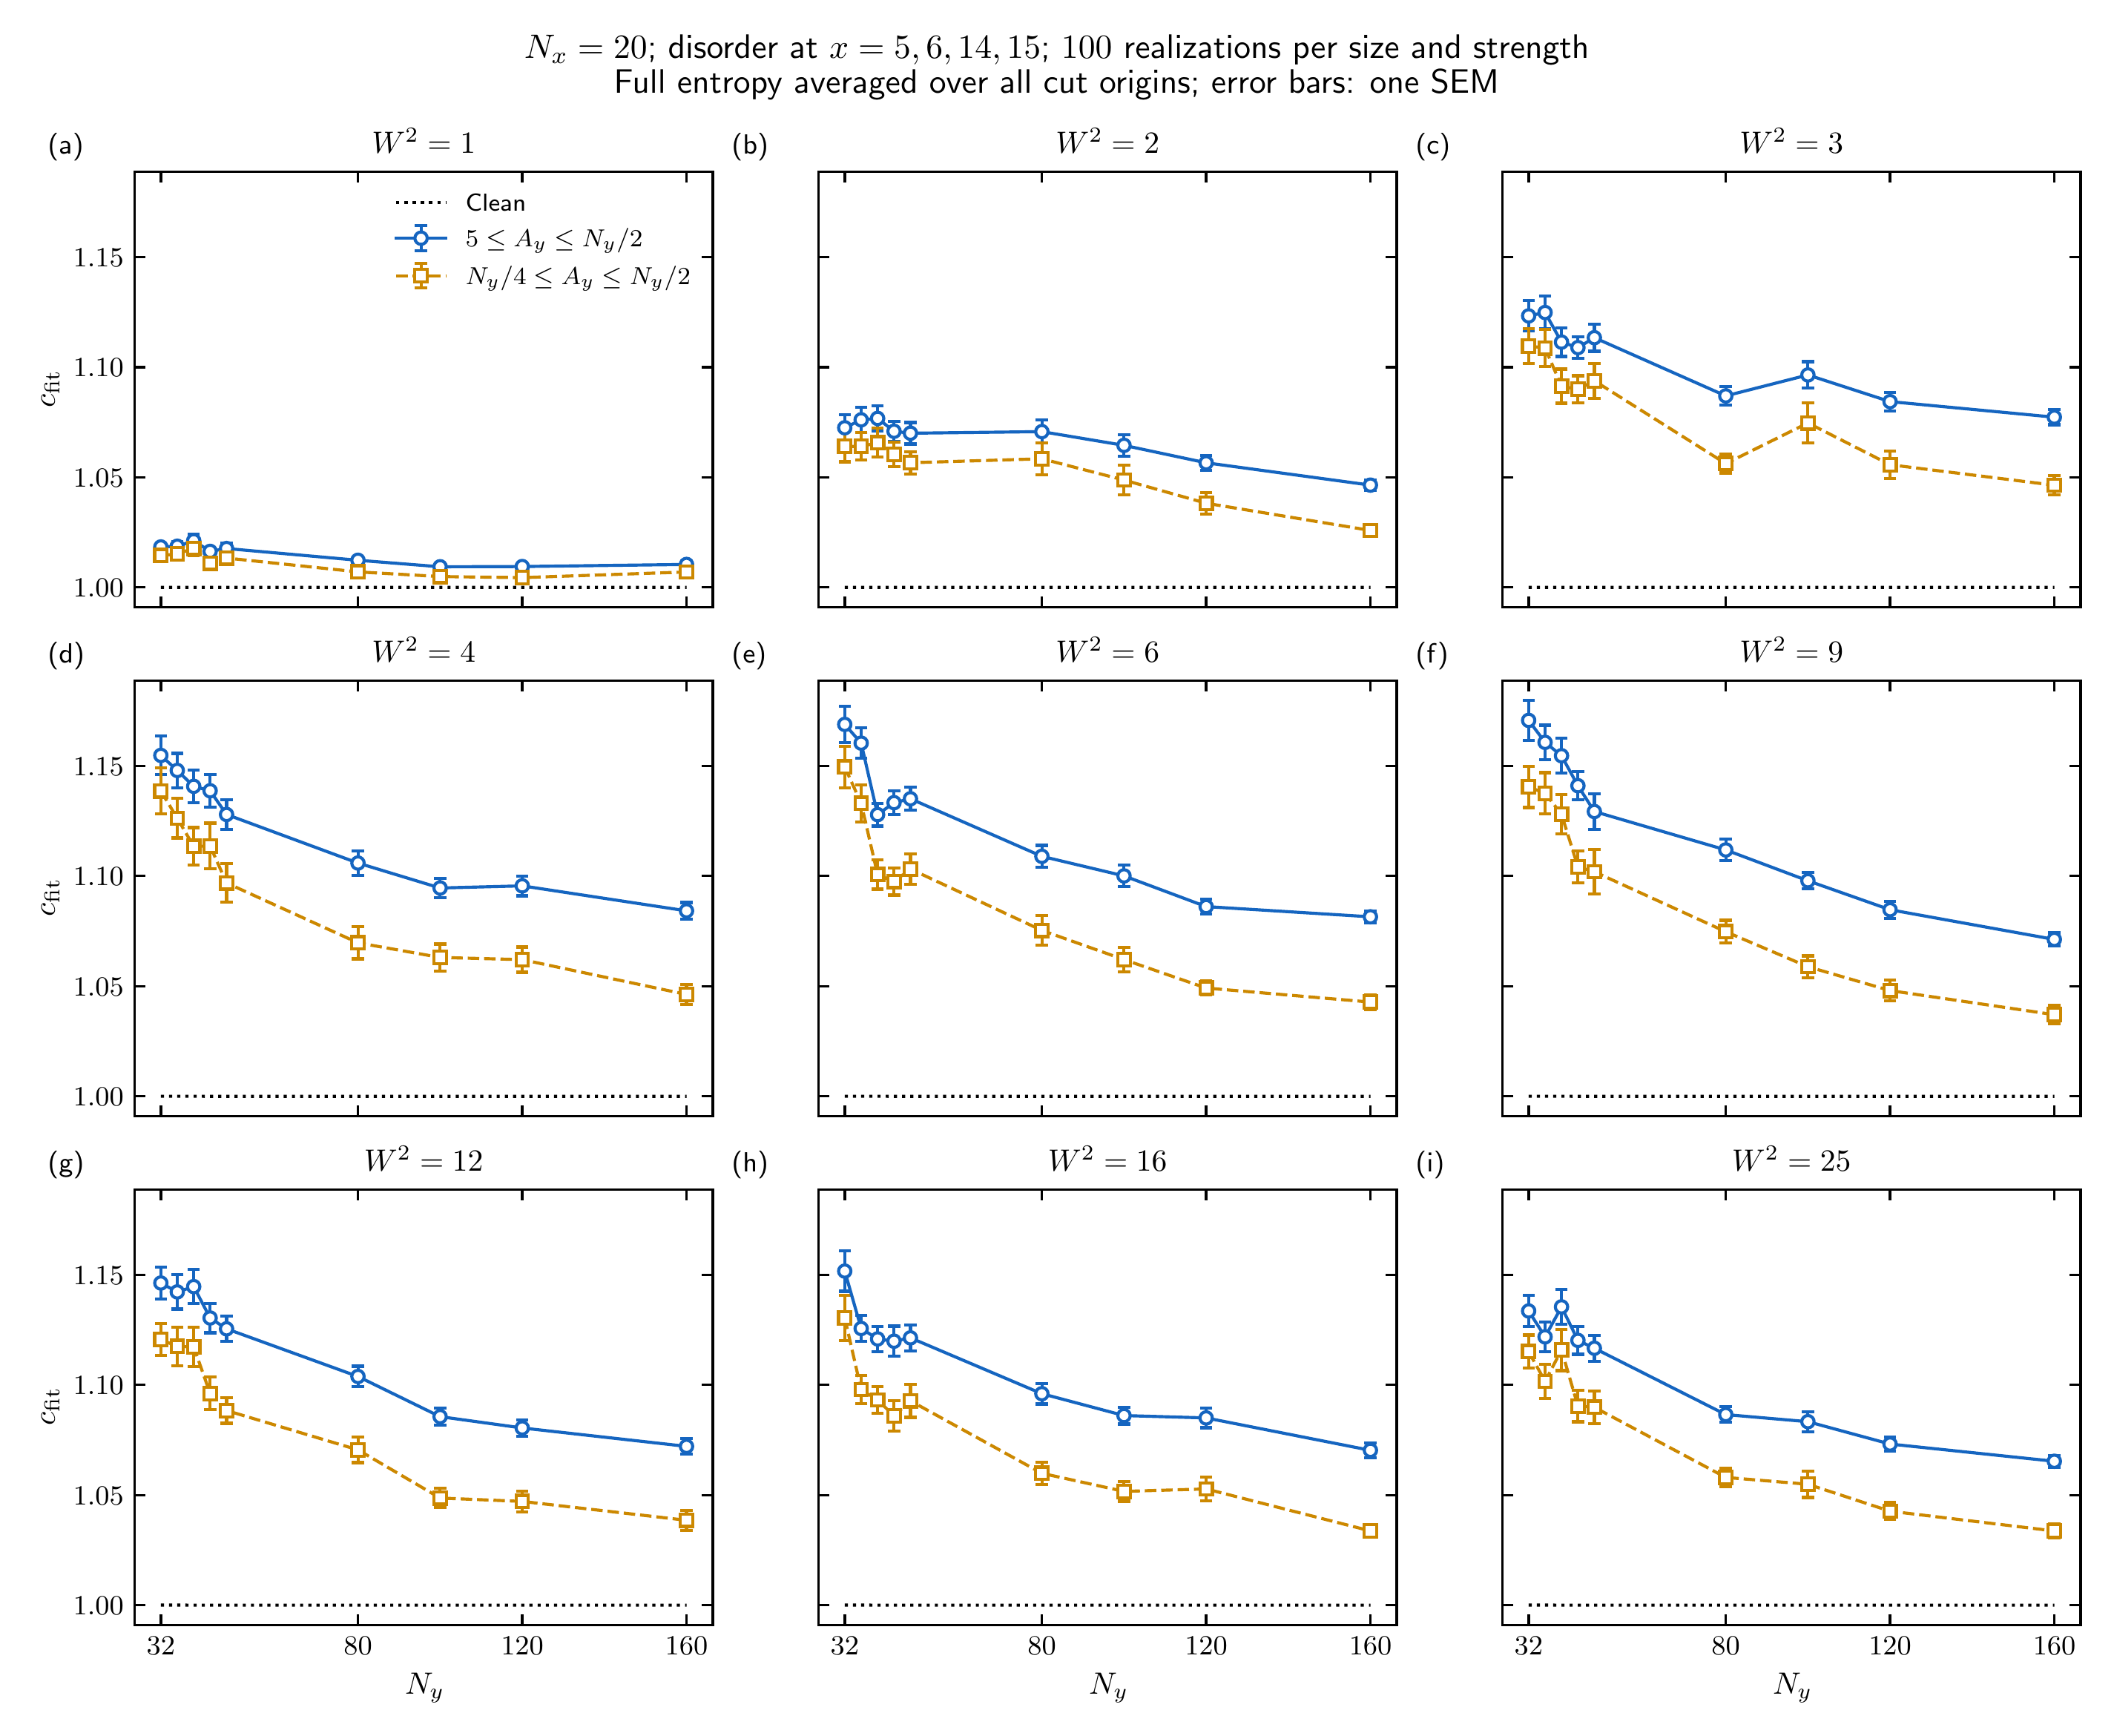

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':9,
 'axes.labelsize':10,'axes.titlesize':10,'text.usetex':True,'text.latex.preamble':r'\usepackage{amsmath,amssymb}',
 'xtick.direction':'in','ytick.direction':'in','legend.frameon':False,'legend.fontsize':8,'pdf.fonttype':42})
fig,axes=plt.subplots(3,3,figsize=(9.5,7.8),sharex=True,sharey=True)
for ax,v,letter in zip(axes.flat,VARIANCES,'abcdefghi'):
    for label,color,fmt,legend in [('fixed5','#1565c0','o-',r'$5\le A_y\le N_y/2$'),
                                  ('quarter','#cc8800','s--',r'$N_y/4\le A_y\le N_y/2$')]:
        t=fits[(fits.variance==v)&(fits.fit_window==label)]
        ax.errorbar(t.Ny,t.c_fit,yerr=t.c_sampling_sem,fmt=fmt,mfc='white',ms=4,lw=1,capsize=2,color=color,label=legend)
    clean=fits[(fits.variance==0)&(fits.fit_window=='quarter')]
    ax.plot(clean.Ny,clean.c_fit,'k:',lw=1,label='Clean')
    ax.set_title(rf'$W^2={v}$');ax.set_xticks([32,80,120,160])
    ax.text(-.15,1.04,f'({letter})',transform=ax.transAxes);ax.tick_params(top=True,right=True)
axes[0,0].legend(loc='best')
for ax in axes[:,0]:ax.set_ylabel(r'$c_{\mathrm{fit}}$')
for ax in axes[-1]:ax.set_xlabel(r'$N_y$')
fig.suptitle(r'$N_x=20$; disorder at $x=5,6,14,15$; $100$ realizations per size and strength'+'\n'+
             r'Full entropy averaged over all cut origins; error bars: one SEM',fontsize=11)
fig.tight_layout(pad=1.2)
fig.savefig(OUT/'central_charge_size_trends.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'central_charge_size_trends.pdf'),str(OUT/'central_charge_size_trends')],check=True)
display(Image(filename=str(OUT/'central_charge_size_trends.png'),width=1100))


## Effective central charge versus disorder
Each panel uses one fitting window, with one curve per system size. Error bars are one SEM across independent disorder realizations. The horizontal coordinate is the disorder variance W^2. Here c_eff is the same 3-times-slope coefficient stored as c_fit in the tables.

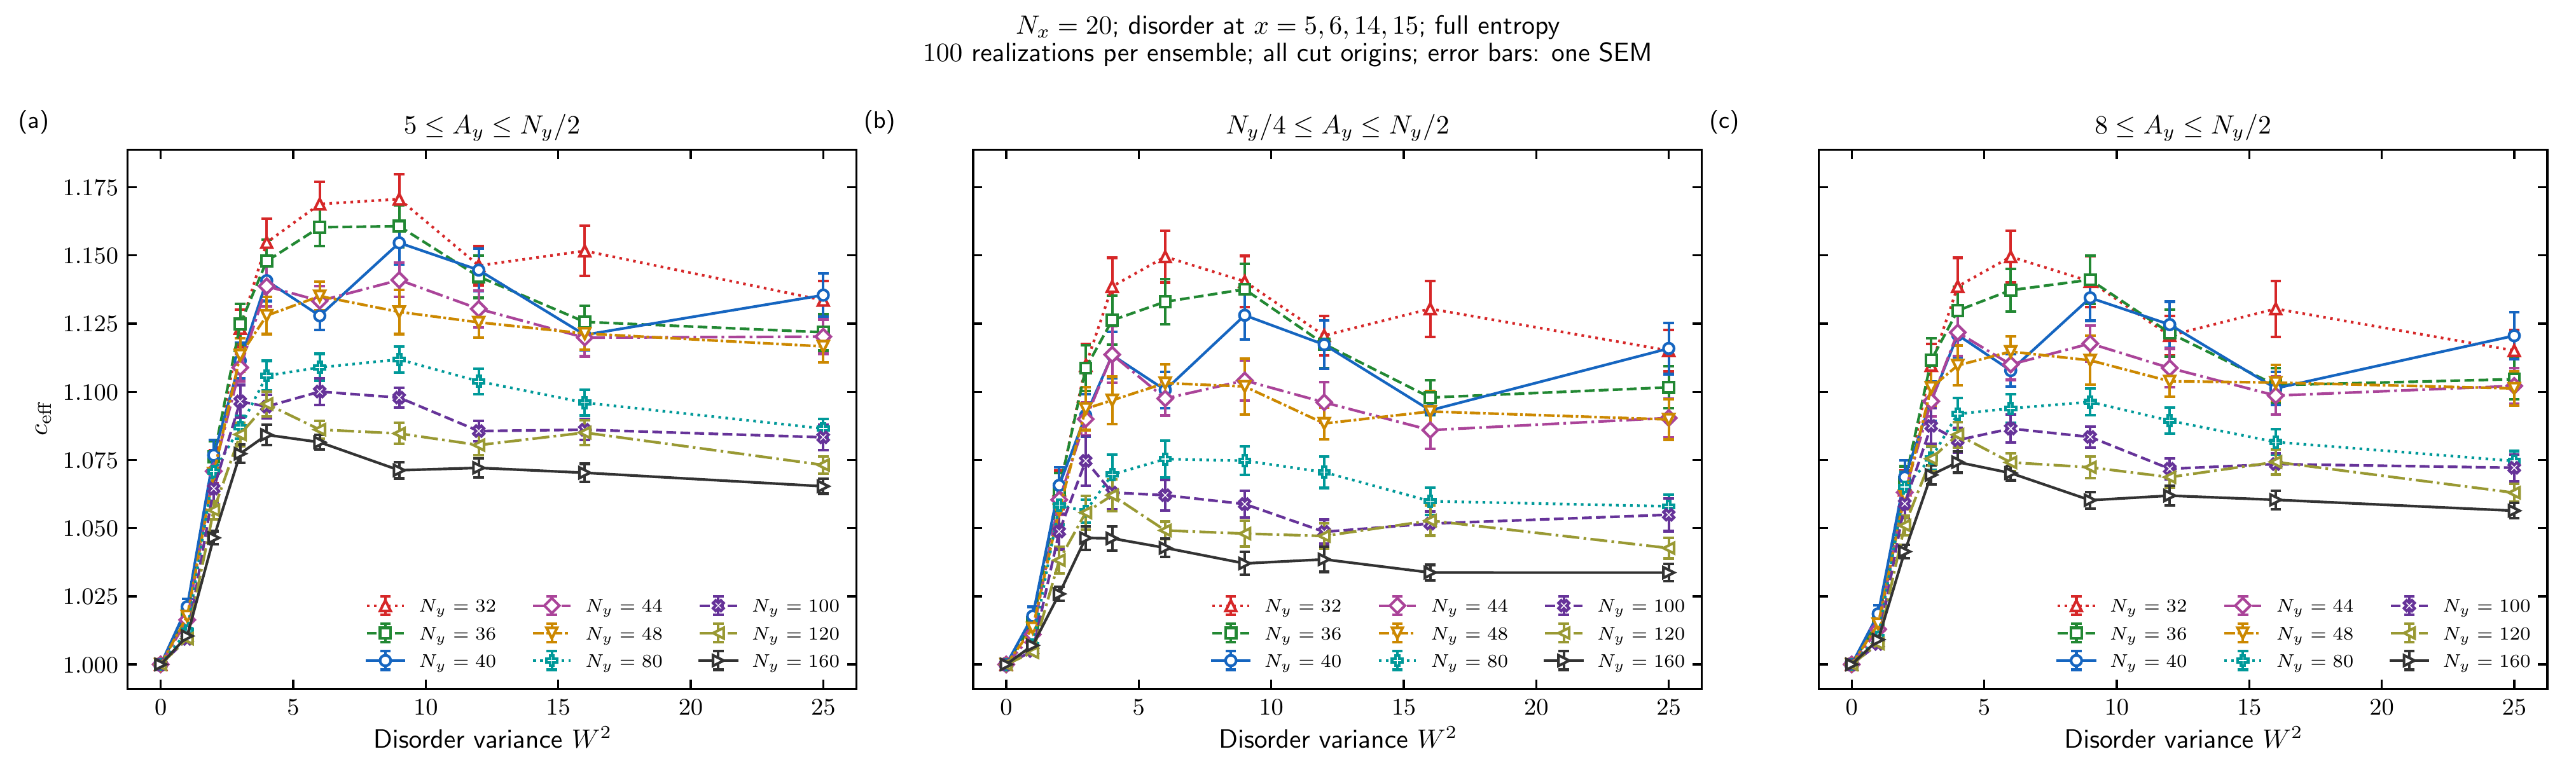

In [5]:
colors=['#d62728','#228833','#1565c0','#aa4499','#cc8800','#009999','#663399','#999933','#333333'];markers=['^','s','o','D','v','P','X','<','>']
styles=[':', '--', '-', '-.', (0,(4,1,1,1)), ':','--','-.','-']
fig,axes=plt.subplots(1,3,figsize=(13.5,4.1),sharex=True,sharey=True)
for ax,window,title,letter in zip(axes,['fixed5','quarter','fixed8'],
        [r'$5\le A_y\le N_y/2$',r'$N_y/4\le A_y\le N_y/2$',r'$8\le A_y\le N_y/2$'],'abc'):
    for ny,color,marker,ls in zip(SIZES,colors,markers,styles):
        t=fits[(fits.Ny==ny)&(fits.fit_window==window)].sort_values('variance')
        ax.errorbar(t.variance,t.c_fit,yerr=t.c_sampling_sem,marker=marker,ls=ls,
                    color=color,mfc='white',ms=4,capsize=2,lw=1,label=rf'$N_y={ny}$')
    ax.set_title(title)
    ax.set_xlabel(r'Disorder variance $W^2$')
    ax.tick_params(top=True,right=True)
    ax.text(-.15,1.04,f'({letter})',transform=ax.transAxes)
    ax.legend(ncol=3,loc='lower right',fontsize=7)
axes[0].set_ylabel(r'$c_{\mathrm{eff}}$')
fig.suptitle(r'$N_x=20$; disorder at $x=5,6,14,15$; full entropy'+'\n'+
             r'$100$ realizations per ensemble; all cut origins; error bars: one SEM',fontsize=10)
fig.tight_layout(pad=1.2)
fig.savefig(OUT/'c_effective_vs_disorder_fit_windows.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'c_effective_vs_disorder_fit_windows.pdf'),str(OUT/'c_effective_vs_disorder_fit_windows')],check=True)
display(Image(filename=str(OUT/'c_effective_vs_disorder_fit_windows.png'),width=1100))


## Entropy-fit curves across sizes
All widths are shown. Gray shading marks the common relative window $N_y/4\le A_y\le N_y/2$. Curves subtract the measured half-system entropy only for display; every fit retains a free intercept.

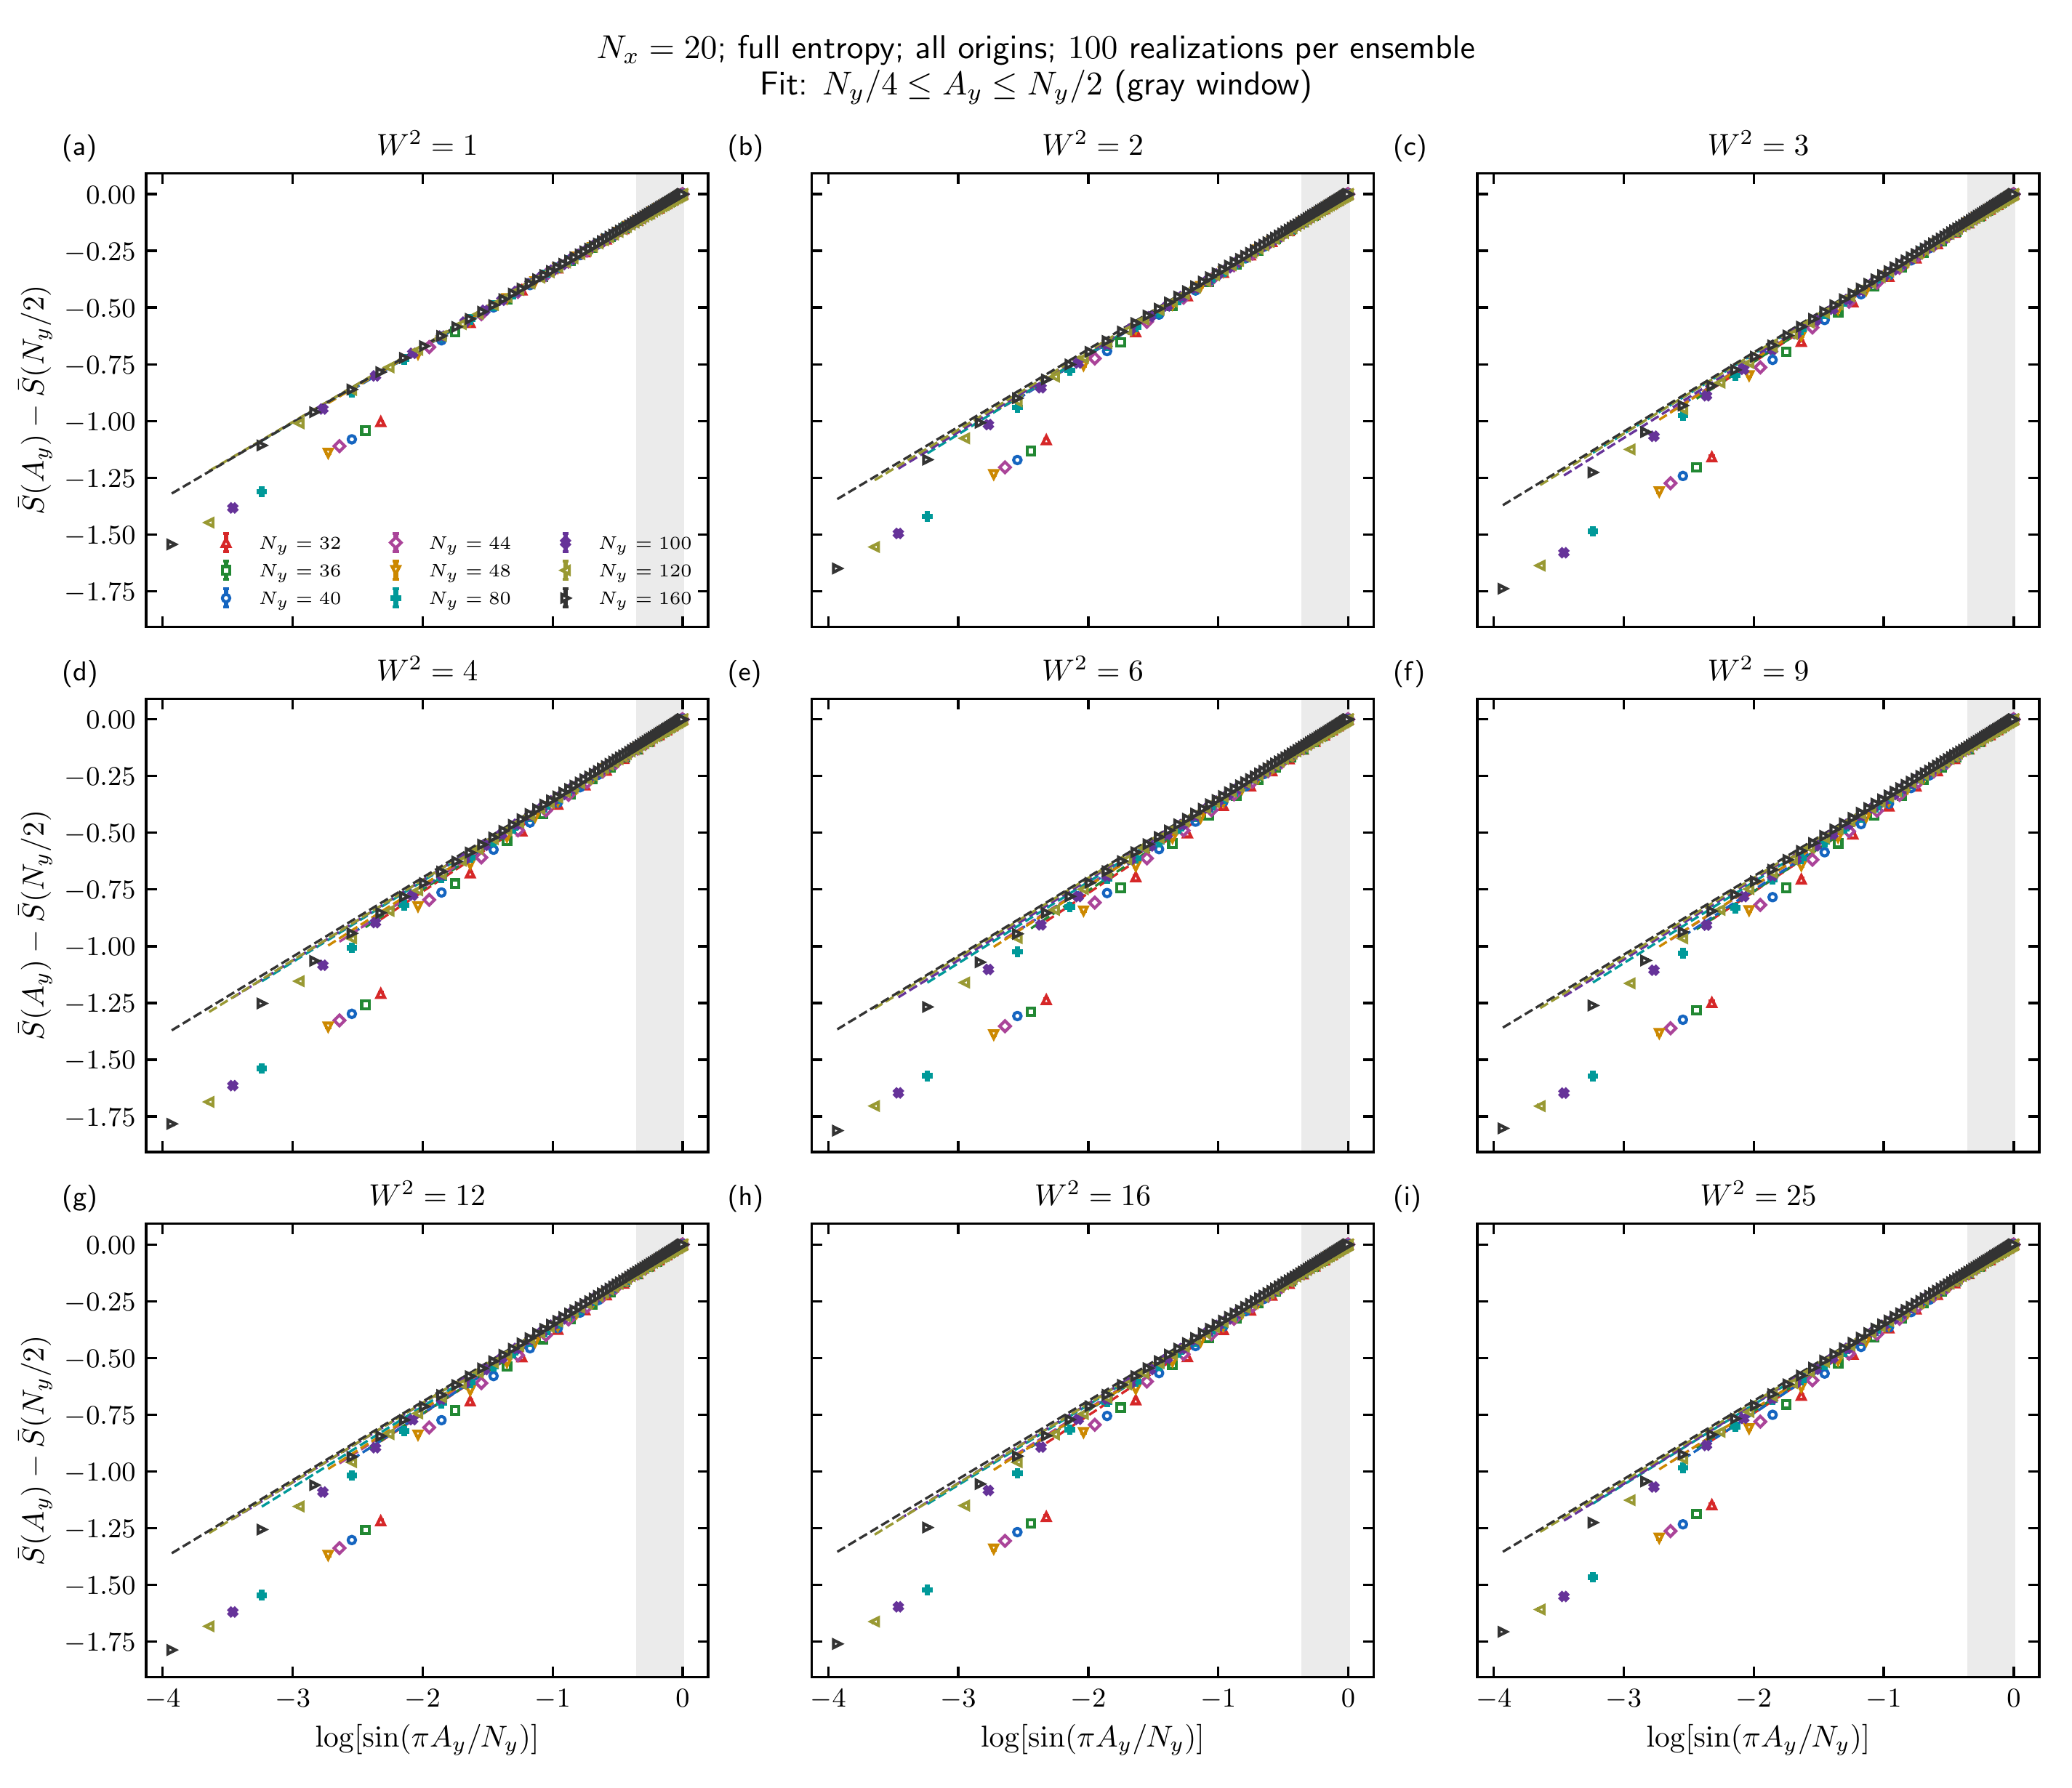

In [6]:
fig,axes=plt.subplots(3,3,figsize=(9.5,8.2),sharex=True,sharey=True)
for i,(ax,v,letter) in enumerate(zip(axes.flat,VARIANCES,'abcdefghi')):
    ax.axvspan(np.log(np.sin(np.pi/4)),0,color='.92',zorder=0)
    for ny,color,marker in zip(SIZES,colors,markers):
        a=profiles[ny][i];shift=a-a[:,-1,None];mean=shift.mean(0);sem=shift.std(0,ddof=1)/10
        xx=np.log(np.sin(np.pi*np.arange(1,ny//2+1)/ny))
        ax.errorbar(xx,mean,yerr=sem,fmt=marker,ms=2.5,mfc='white',capsize=1,color=color,label=rf'$N_y={ny}$')
        ax.plot(xx,curves[(ny,v,'quarter')]-a.mean(0)[-1],color=color,ls='--',lw=.8)
    ax.set_title(rf'$W^2={v}$');ax.text(-.15,1.04,f'({letter})',transform=ax.transAxes)
    ax.tick_params(top=True,right=True)
axes[0,0].legend(ncol=3,loc='lower right',fontsize=6)
for ax in axes[:,0]:ax.set_ylabel(r'$\bar S(A_y)-\bar S(N_y/2)$')
for ax in axes[-1]:ax.set_xlabel(r'$\log[\sin(\pi A_y/N_y)]$')
fig.suptitle(r'$N_x=20$; full entropy; all origins; $100$ realizations per ensemble'+'\n'+
             r'Fit: $N_y/4\le A_y\le N_y/2$ (gray window)',fontsize=11)
fig.tight_layout(pad=1.2)
fig.savefig(OUT/'entropy_fits_across_sizes.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'entropy_fits_across_sizes.pdf'),str(OUT/'entropy_fits_across_sizes')],check=True)
display(Image(filename=str(OUT/'entropy_fits_across_sizes.png'),width=1100))


## Diagnostics and limits
Check exact block reduction against full-matrix ground states at clean and strongest disorder for each new size, including periodic wrapping cuts. State-level checks cover Hermiticity, finite physical occupations, traces, purity, and complement symmetry. Changes across sizes describe this finite strip; the sampling intervals exclude fit-range and finite-size systematic effects.

In [7]:
for ny in SIZES[1:]:
    r=acquisition[ny]
    assert r['diagnostic_maxima']['purity_error']<1e-10
    assert r['diagnostic_maxima']['trace_error']<1e-8
    assert r['diagnostic_maxima']['complement_error']<1e-7
    assert max(r['full_space_checks'])<1e-7
diagnostics={'acquisition':acquisition,'bootstrap':{'replicates':BOOTSTRAPS,'seed':BOOTSTRAP_SEED,'unit':'whole realization'},
             'independent_sizes':True,'primary_window':'5..Ny/2','controlled_relative_window':'ceil(Ny/4)..Ny/2',
             'fits':fits.to_dict('records'),'trends':trends,'Ny32_prior_coefficients_reproduced':True}
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(primary[['Ny','variance','c_fit','c_sampling_sem','R_squared']])
print('Complete: 3600 new disordered states, four clean states, and verified Ny32--48 references.')


,Ny,variance,c_fit,c_sampling_sem,R_squared
0,32,0,1.000042,0.000000,1.000000
5,32,1,1.018360,0.001175,0.999995
10,32,2,1.072474,0.006049,0.999978
15,32,3,1.123277,0.006939,0.999946
20,32,4,1.154771,0.008733,0.999921
...,...,...,...,...,...
425,160,6,1.081488,0.002637,0.999645
430,160,9,1.071211,0.002980,0.999672
435,160,12,1.072094,0.003470,0.999718
440,160,16,1.070295,0.003285,0.999723


Complete: 3600 new disordered states, four clean states, and verified Ny32--48 references.
